In [1]:
import tensorflow as tf
from  tensorflow.keras.datasets  import  imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from  tensorflow.keras.preprocessing.sequence  import  pad_sequences
import matplotlib.pyplot as plt
import numpy as np


In [3]:
# Load IMDB dataset (top 10,000 most frequent words)
vocab_size = 10000
(x_train,  y_train),  (x_test,  y_test)  =  imdb.load_data(num_words=vocab_size)
print("Training samples:", len(x_train)) 
print("Testing samples:", len(x_test))


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 12s 1us/step
Training samples: 25000
Testing samples: 25000


In [4]:
# Pad sequences to same length
max_length = 200
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)


In [5]:
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=128,input_length=max_length))
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))
model.summary()


D:\user\envs\tanubhalerao\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile( optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']
)


In [7]:
history = model.fit( x_train,  y_train, epochs=10, batch_size=64,
validation_split=0.2
)


Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 154s 479ms/step - accuracy: 0.7651 - loss: 0.4755 - val_accuracy: 0.8470 - val_loss: 0.3569
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 138s 441ms/step - accuracy: 0.8893 - loss: 0.2786 - val_accuracy: 0.8634 - val_loss: 0.3398
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 149s 476ms/step - accuracy: 0.9220 - loss: 0.2025 - val_accuracy: 0.8670 - val_loss: 0.3352
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 167s 533ms/step - accuracy: 0.9452 - loss: 0.1494 - val_accuracy: 0.8644 - val_loss: 0.3618
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1585s 5s/step - accuracy: 0.9571 - loss: 0.1225 - val_accuracy: 0.8424 - val_loss: 0.4216
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 235s 750ms/step - accuracy: 0.9640 - loss: 0.1030 - val_accuracy: 0.8158 - val_loss: 0.4955
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1241s 4s/step - accuracy: 0.9761 - loss: 0.0734 - val_accuracy: 0.8486 - val_loss: 0.5182
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 176s 561ms/step - accuracy: 0.9866 - los

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - accuracy: 0.8386 - loss: 0.6607
Test Accuracy: 0.8386399745941162


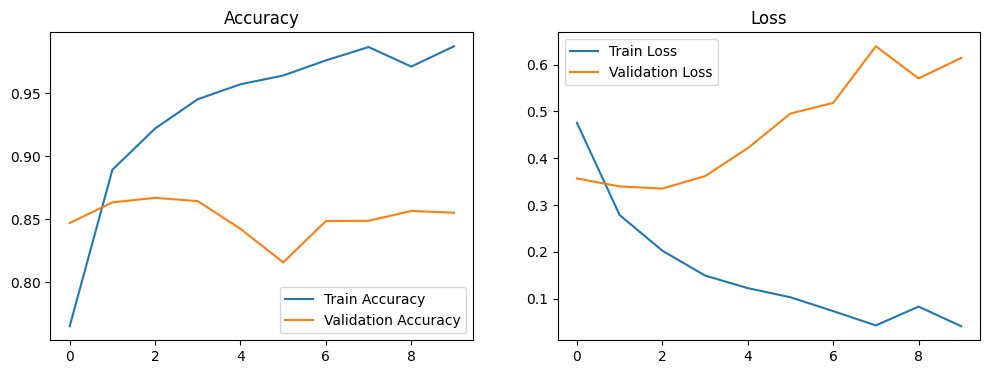

In [ ]:
plt.figure(figsize=(12,4))
# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy') 
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss') 
plt.legend()
plt.title("Loss")
plt.show()


In [ ]:
# Example review (encoded manually for demo) sample_review = x_test[0].reshape(1, -1) prediction = model.predict(sample_review)
if prediction > 0.3: print("Positive Review")
else:
print("Negative Review")


IndentationError: expected an indented block after 'else' statement on line 3 (544770434.py, line 4)